In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# SINDy - Example 2: Lorenz system


Here we replicate Example 2 of {cite:t}`brunton2016discovering`.
The Lorenz dynamics are:


\begin{align}
\dot{x} &= \sigma(y - x) \\
\dot{y} &= x(\rho - z) - y \\
\dot{z} &= xy - \beta z.
\end{align}


We take $\sigma = 10$, $\rho = 28$, and $\beta = 8/3$.

We are going to experiment with adding noise to the derivatives.



In [3]:
import numpy as np
import scipy

sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0
dt = 0.001
num_steps = int(100.0 / dt)
ts = np.linspace(0, 100, num_steps)
x0 = np.array([-8.0, 7.0, 27.0])

def vector_field(x, t):
    return (
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - beta * x[2]
    )
xs = scipy.integrate.odeint(vector_field, x0, ts)

# Find the exact derivatives - no noise
from jax import vmap, jit
vf = jit(vmap(vector_field, in_axes=(0, 0)))
dxs = np.array(vf(xs, ts)).T

I had trouble replicating this problem using `LassoCV`. The inputs and outputs need scaling and even with scaling, it takes too many iterations to run and the results were not good.
I am going to use the sequentially thresholded least-squares approach described by {cite:t}`brunton2019datadriven`.
I reimplement the code from the book here:

In [4]:
def sparsify_dynamics(Phi, dxs, alpha, max_iter=100):
    """Solve the sparse regression problem to find the dynamics of the system.
    
    Args:
        Phi: The basis functions evaluated at each point in the state space.
        dxs: The time derivatives of the state space points.
        alpha: The sparsity parameter.
        max_iter: The maximum number of iterations to run the optimization.
    """
    thetas = np.linalg.lstsq(Phi, dxs, rcond=None)[0]
    d = dxs.shape[1]
    for _ in range(max_iter):
        smallinds = np.abs(thetas) < alpha
        thetas[smallinds] = 0
        for ind in range(d):
            biginds = smallinds[:, ind] == 0
            thetas[biginds, ind] = np.linalg.lstsq(Phi[:, biginds], dxs[:, ind], rcond=None)[0]
    return thetas

Solve the problem:

In [5]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5)
Phi = poly.fit_transform(xs)

thetas = sparsify_dynamics(Phi, dxs, 0.025)

Let's look at the coefficients:

In [6]:
for j in range(thetas.shape[1]):
    print(f"Dynamics of x_{j+1}:")
    print("-" * 20)
    for i, name in enumerate(poly.get_feature_names_out()):
        print(f"{name:10s} = {thetas[i][j]:.2f}") 

Dynamics of x_1:
--------------------
1          = 0.00
x0         = -10.00
x1         = 10.00
x2         = 0.00
x0^2       = 0.00
x0 x1      = 0.00
x0 x2      = 0.00
x1^2       = 0.00
x1 x2      = 0.00
x2^2       = 0.00
x0^3       = 0.00
x0^2 x1    = 0.00
x0^2 x2    = 0.00
x0 x1^2    = 0.00
x0 x1 x2   = 0.00
x0 x2^2    = 0.00
x1^3       = 0.00
x1^2 x2    = 0.00
x1 x2^2    = 0.00
x2^3       = 0.00
x0^4       = 0.00
x0^3 x1    = 0.00
x0^3 x2    = 0.00
x0^2 x1^2  = 0.00
x0^2 x1 x2 = 0.00
x0^2 x2^2  = 0.00
x0 x1^3    = 0.00
x0 x1^2 x2 = 0.00
x0 x1 x2^2 = 0.00
x0 x2^3    = 0.00
x1^4       = 0.00
x1^3 x2    = 0.00
x1^2 x2^2  = 0.00
x1 x2^3    = 0.00
x2^4       = 0.00
x0^5       = 0.00
x0^4 x1    = 0.00
x0^4 x2    = 0.00
x0^3 x1^2  = 0.00
x0^3 x1 x2 = 0.00
x0^3 x2^2  = 0.00
x0^2 x1^3  = 0.00
x0^2 x1^2 x2 = 0.00
x0^2 x1 x2^2 = 0.00
x0^2 x2^3  = 0.00
x0 x1^4    = 0.00
x0 x1^3 x2 = 0.00
x0 x1^2 x2^2 = 0.00
x0 x1 x2^3 = 0.00
x0 x2^4    = 0.00
x1^5       = 0.00
x1^4 x2    = 0.00
x1^3 x2^2  = 0.00

The identified dynamics reproduce the training data closely. We now make predictions with the identified model.

In [7]:
dt = 0.001
num_steps = int(250.0 / dt)
ts = np.linspace(0, 250, num_steps)

# Simulate with the original dynamics
xs = scipy.integrate.odeint(vector_field, x0, ts)

# Simulate with the learned dynamics
def f_learned(x, t, thetas, poly):
    phi = poly.fit_transform(x.reshape(1, -1)).flatten()
    dx = np.zeros(x.shape[0])
    for j in range(x.shape[0]):
        dx[j] = np.dot(thetas[:, j], phi)
    return dx

xs_learned = scipy.integrate.odeint(lambda x, t: f_learned(x, t, thetas, poly), x0, ts)

Compare visually the attractors:

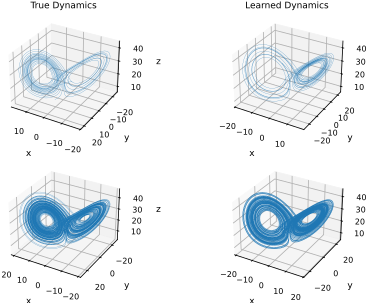

In [8]:
fig = plt.figure(figsize=FIGURE_SIZES["full_standard"])
ax1 = fig.add_subplot(221, projection='3d')
steps = int(20/dt)
ax1.plot(xs[:steps, 0], xs[:steps, 1], xs[:steps, 2], lw=0.2)
ax1.set(xlabel='x', ylabel='y', zlabel='z', title='True Dynamics')
ax1.view_init(30, 120)

ax2 = fig.add_subplot(222, projection='3d')
ax2.plot(xs_learned[:steps, 0], xs_learned[:steps, 1], xs_learned[:steps, 2], lw=0.2)
ax2.set(xlabel='x', ylabel='y', zlabel='z', title='Learned Dynamics')
ax1.view_init(30, 120)

ax3 = fig.add_subplot(223, projection='3d')
ax3.plot(xs[:, 0], xs[:, 1], xs[:, 2], lw=0.2)
ax3.set(xlabel='x', ylabel='y', zlabel='z')
ax3.view_init(30, 120)

ax4 = fig.add_subplot(224, projection='3d')
ax4.plot(xs_learned[:, 0], xs_learned[:, 1], xs_learned[:, 2], lw=0.2)
ax4.set(xlabel='x', ylabel='y', zlabel='z')
ax3.view_init(30, 120);


This replicates the first two columns of Figure 4 in {cite:t}`brunton2016discovering`, without the color or noise.
You see that the dynamics do not match perfectly (because the system is chaotic), but the attractors are very similar.

Let's also plot the dynamo view:

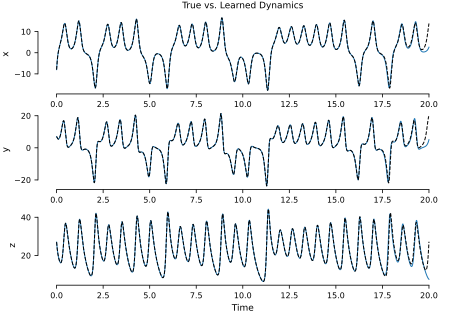

In [9]:
fig = plt.figure(figsize=FIGURE_SIZES["full_standard"])
ax1 = fig.add_subplot(311)
steps = int(20/dt)
ax1.plot(ts[:steps], xs[:steps, 0], lw=1.0, label='True Dynamics')
ax1.plot(ts[:steps], xs_learned[:steps, 0], 'k--', lw=1.0, label='Learned Dynamics')
ax1.set(xlabel='Time', ylabel='x', title='True vs. Learned Dynamics')
finalize_axes(keep_box=False)

ax2 = fig.add_subplot(312)
ax2.plot(ts[:steps], xs[:steps, 1], lw=1.0, label='True Dynamics')
ax2.plot(ts[:steps], xs_learned[:steps, 1], 'k--', lw=1.0, label='Learned Dynamics')
ax2.set(xlabel='Time', ylabel='y')

ax3 = fig.add_subplot(313)
ax3.plot(ts[:steps], xs[:steps, 2], lw=1.0, label='True Dynamics')
ax3.plot(ts[:steps], xs_learned[:steps, 2], 'k--', lw=1.0, label='Learned Dynamics')
ax3.set(xlabel='Time', ylabel='z')
sns.despine(trim=True);


This reproduces Figure 5 in {cite:t}`brunton2016discovering`, without the noise.

Let's repeat the same analysis, but this time we are going to add noise to the derivatives. The noise is zero mean, independent Gaussian with standard deviation $\eta$.

In [10]:
# Noise level:
eta = 10.0

dxs_noisy = dxs + eta * np.random.randn(*dxs.shape)

# retrain
thetas_noisy = sparsify_dynamics(Phi, dxs_noisy, 0.025)

Repeat the plots above:

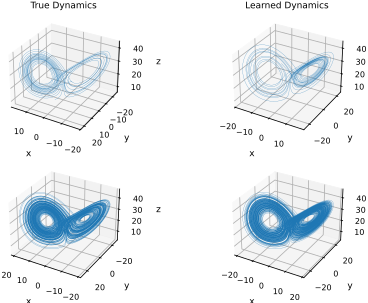

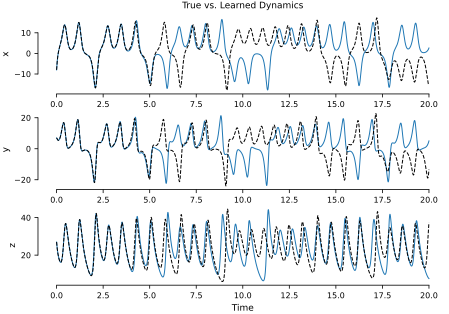

In [11]:
xs_learned = scipy.integrate.odeint(lambda x, t: f_learned(x, t, thetas_noisy, poly), x0, ts)

fig = plt.figure(figsize=FIGURE_SIZES["full_standard"])
ax1 = fig.add_subplot(221, projection='3d')
steps = int(20/dt)
ax1.plot(xs[:steps, 0], xs[:steps, 1], xs[:steps, 2], lw=0.2)
ax1.set(xlabel='x', ylabel='y', zlabel='z', title='True Dynamics')
ax1.view_init(30, 120)

ax2 = fig.add_subplot(222, projection='3d')
ax2.plot(xs_learned[:steps, 0], xs_learned[:steps, 1], xs_learned[:steps, 2], lw=0.2)
ax2.set(xlabel='x', ylabel='y', zlabel='z', title='Learned Dynamics')
ax1.view_init(30, 120)

ax3 = fig.add_subplot(223, projection='3d')
ax3.plot(xs[:, 0], xs[:, 1], xs[:, 2], lw=0.2)
ax3.set(xlabel='x', ylabel='y', zlabel='z')
ax3.view_init(30, 120)

ax4 = fig.add_subplot(224, projection='3d')
ax4.plot(xs_learned[:, 0], xs_learned[:, 1], xs_learned[:, 2], lw=0.2)
ax4.set(xlabel='x', ylabel='y', zlabel='z')
ax3.view_init(30, 120);

fig = plt.figure(figsize=FIGURE_SIZES["full_standard"])
ax1 = fig.add_subplot(311)
steps = int(20/dt)
ax1.plot(ts[:steps], xs[:steps, 0], lw=1.0, label='True Dynamics')
ax1.plot(ts[:steps], xs_learned[:steps, 0], 'k--', lw=1.0, label='Learned Dynamics')
ax1.set(xlabel='Time', ylabel='x', title='True vs. Learned Dynamics')
finalize_axes(keep_box=False)

ax2 = fig.add_subplot(312)
ax2.plot(ts[:steps], xs[:steps, 1], lw=1.0, label='True Dynamics')
ax2.plot(ts[:steps], xs_learned[:steps, 1], 'k--', lw=1.0, label='Learned Dynamics')
ax2.set(xlabel='Time', ylabel='y')

ax3 = fig.add_subplot(313)
ax3.plot(ts[:steps], xs[:steps, 2], lw=1.0, label='True Dynamics')
ax3.plot(ts[:steps], xs_learned[:steps, 2], 'k--', lw=1.0, label='Learned Dynamics')
ax3.set(xlabel='Time', ylabel='z')
sns.despine(trim=True);


We see that the particular trajectories are not accurate after a while.
The system is chaotic, so this is expected.
Tiny errors will be magnified over time.
But the attractor looks great.